# 3 — Comparison with PDHG

Learned scheme against PDHG (Chambolle–Pock), the standard solver for TGV$^2$,
on one held-out Mayo slice. PDHG has no state $(p, q)$ comparable to ours, so
the comparison uses the objective value, the PSNR and the run time (no KKT
residual). Run `main.py` first.

Figures and the time table are saved in `plots/` (prefix `3_`).

In [10]:
import torch

from utils.experiments import (build_test_instance, reference_solution, run_fbs,
                               random_direction, objective_gap, time_table, load_model)
from utils.plots import apply_paper_style, plot_curves, show_images
from utils.pdhg_tomography_tgv import run_pdhg

apply_paper_style()

In [ ]:
# --- configuration (must match main.py) ---------------------------------------
SIZE = 128
N_ANGLES = 180
NOISE_LEVEL = 0.05
GAMMA = 2
PRIMAL_STEP = 1.5          # primal step tau (see main.py)

TEST_PATIENT = "L014"      # never used for training or validation
TEST_SLICE = 0
MAYO_CACHE_DIR = "./data/mayo_cache_128"
CKPT = "kkt_tomo_128_gamma_2_objective_alpha_04.pt"    # written by main.py

T_TRAIN = 10               # unrolling horizon used in training
T_LONG = 100               # length of the convergence curves
T_REF = 6000               # length of the run that defines F* (cached in results/)

In [12]:
inst = build_test_instance(SIZE, N_ANGLES, NOISE_LEVEL, GAMMA, TEST_PATIENT, TEST_SLICE,
                           MAYO_CACHE_DIR, primal_step=PRIMAL_STEP)
ref = reference_solution(inst, T_REF)
print(f"F* = {ref['f_star']:.4f}, PSNR of the TGV2 solution = {ref['psnr']:.2f} dB")

ValueError: input tensor has wrong shape: expected (N, *, 128, 128), got (1, 1, 512, 512)

In [ ]:
model, ckpt = load_model(CKPT, inst, T=T_TRAIN)

## Runs

In [ ]:
results = {
    "Learned": run_fbs(inst, T_LONG, model, snapshots=(T_TRAIN,)),
    "Zero deviation": run_fbs(inst, T_LONG, snapshots=(T_TRAIN,)),
    "PDHG": run_pdhg(inst["setup"], inst["params"], inst["objective"], inst["clean"],
                     T_LONG, snapshots=(T_TRAIN,)),
}

## Convergence

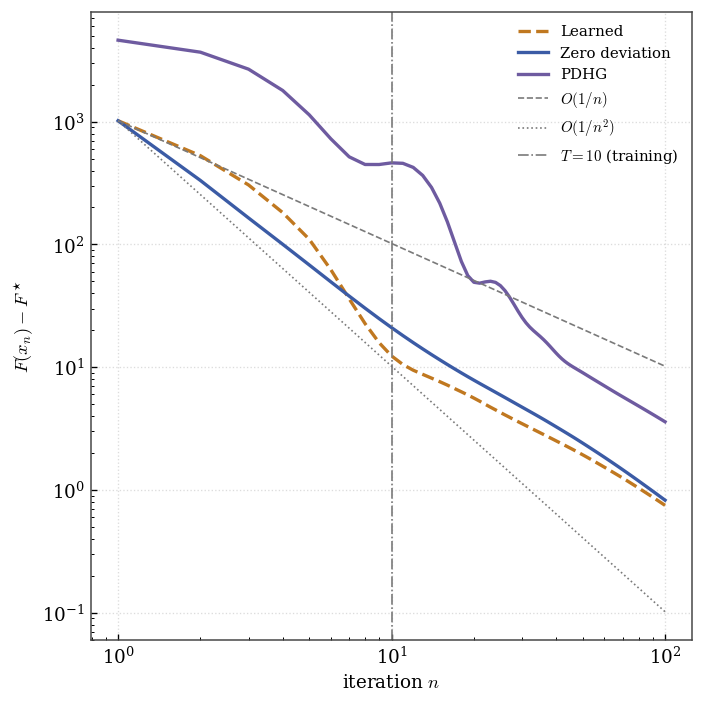

In [ ]:
gaps = {label: objective_gap(r, ref["f_star"]) for label, r in results.items()}
plot_curves(gaps, r"$F(x_n) - F^\star$", "3_objective_gap", slopes=True, horizon=T_TRAIN, show=True)

## PSNR

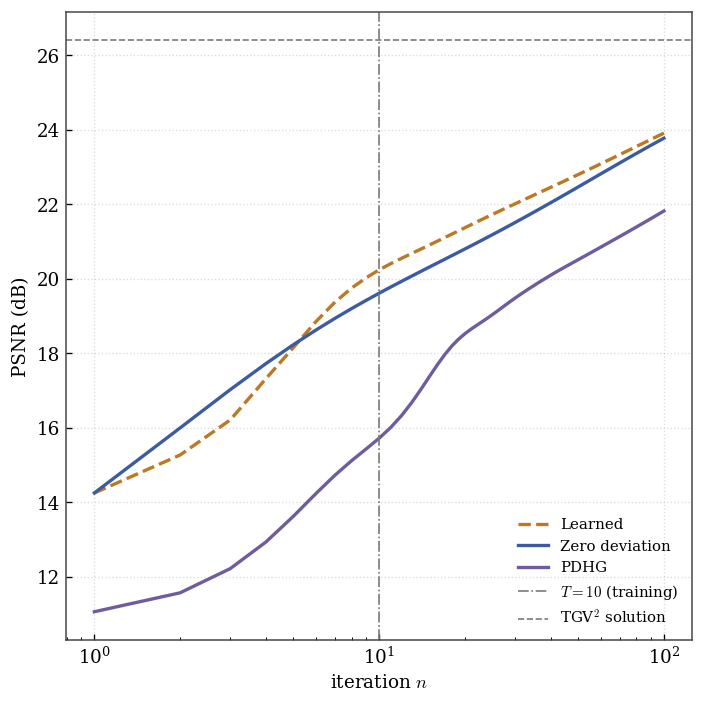

In [ ]:
plot_curves({label: r["psnr"] for label, r in results.items()}, "PSNR (dB)", "3_psnr",
            loglog=False, horizon=T_TRAIN, hline=(ref["psnr"], r"TGV$^2$ solution"), show=True)

## Reconstructions

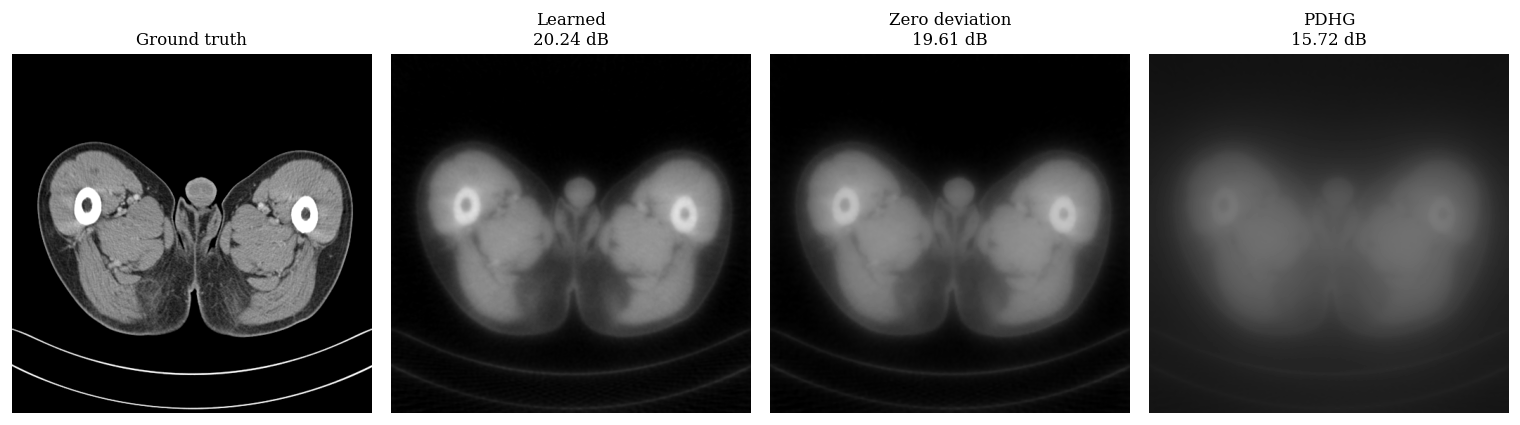

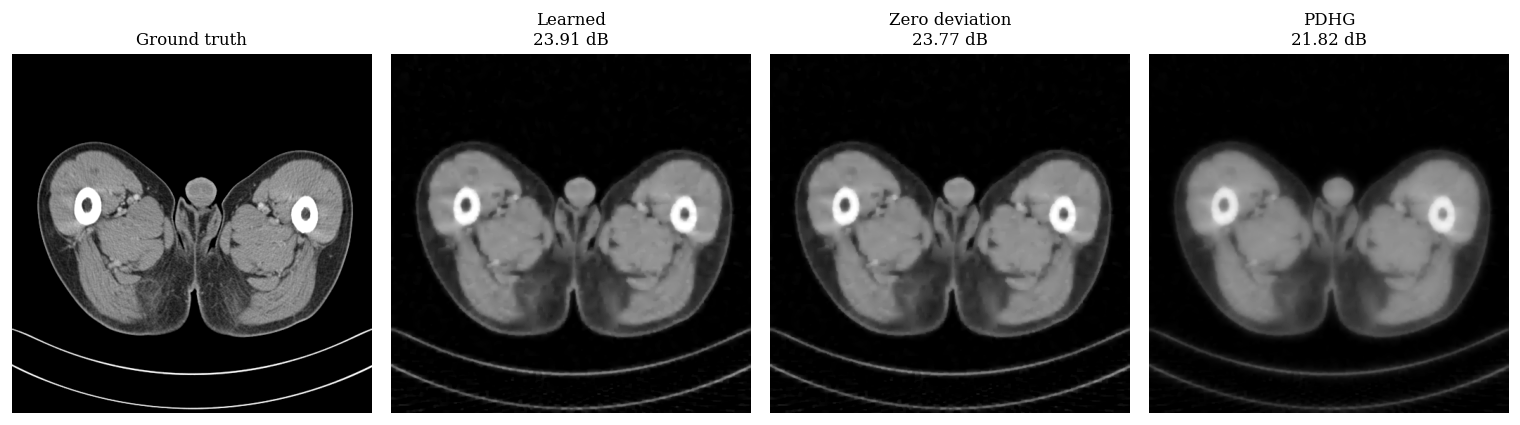

In [ ]:
def gallery(n):
    """Ground truth and the reconstruction of every method after n iterations."""
    images = {"Ground truth": inst["clean"]}
    for label, r in results.items():
        images[f"{label}\n{r['psnr'][n - 1]:.2f} dB"] = r["images"][n]
    return images

show_images(gallery(T_TRAIN), "3_reconstructions_{}_iterations".format(T_TRAIN), show=True)
show_images(gallery(T_LONG), "3_reconstructions_{}_iterations".format(T_LONG), show=True)

## Time comparison

Time per iteration is measured on a separate short run without any monitoring
(no KKT residual, objective or PSNR computed). The table is also written as
LaTeX in `plots/`.

In [ ]:
time_table(results, name="3_time_comparison")

,Time / iteration (ms),PSNR after 10 it. (dB)
Method,,
Learned,94,20.24
Zero deviation,28,19.61
PDHG,43,15.72
